# Rossmann Store Sales Forecasting

## Executive Summary

This project forecasts combined daily sales for 223 Rossmann stores selected using 1 January-3 July 2015 sales. They contribute 30.5% of the supplied 1,115 stores' sales in that period. Only Rossmann_train.csv is analysed, with chronological splits and complete portfolio coverage.

The original linear regression, trained on 730 days, reduces July daily MAE from the weekday baseline's 264,217 to 109,611 (58.5%). Its four-week forecast is 57.33 million versus 56.54 million actual sales (+1.40%). Three earlier 28-day windows also favour it on daily errors, but one total underforecast reaches 8.99% and one holiday forecast is negative.

The seven-procedure comparison ranks a fixed random forest first by mean daily MAE (160,118), 0.95% below Trend and 2.52% below Regression. Trend has lower mean RMSE and total error. Forest's July MAE is 138,087, above Regression's; four-date holiday MAE is 48,195 with no negative forecasts. These are descriptive development findings. Forest is the candidate for fresh validation, with Trend and Regression retained as references. No inspected period is an untouched final test, and operational revenue targets still require human review.

## 1. Business Problem and Data

Sales forecasting supports revenue planning when opening schedules, promotions and calendar effects change. The analysis selects the highest-sales 20% of stores. The selected 223 stores account for **30.5% of sales across the supplied 1,115 stores during 1 January-3 July 2015**, calculated in Section 3.3. This gives managers a focused planning reference for a substantial share of the observed revenue.

The supplied Kaggle training data [1], `Rossmann_train.csv`, contain 1,017,209 store-day observations from 1,115 stores between 1 January 2013 and 31 July 2015. This notebook reads the original data, losslessly compressed as `data/raw/Rossmann_train.csv.gz` in the same repository, and reproduces the cleaning before analysis. Store metadata and the competition test file are outside this analysis scope.

Each row describes **one store on one date**, including recorded closed days. The nine fields have the following roles:

| Field(s) | Meaning and analytical role |
|---|---|
| `Store`, `Date` | Store identifier and calendar date; together identify a store-day. |
| `Sales` | Daily store sales; numeric target, aggregated for the selected portfolio. |
| `Customers` | Daily customer count; historical EDA only, as future counts are unavailable. |
| `DayOfWeek` | Weekday category: 1 = Monday through 7 = Sunday. |
| `Open`, `Promo` | Binary flags: 1 = open / promotion, 0 = closed / no promotion. |
| `StateHoliday` | Holiday category: `0` = none; `a`, `b`, `c` mark holiday types. |
| `SchoolHoliday` | Binary flag: 1 = school holiday, 0 = no school holiday. |

Sales retain the dataset's original units; no currency conversion is applied. Opening and promotion flags are assumed to reflect advance plans for the historical forecasting exercise (Section 5.1).

> **How accurately can Rossmann forecast the combined daily sales of its top 20% highest-sales stores over the next 28 days to support short-term revenue planning?**

Supporting question: **Which observable factors are associated with daily sales among the selected stores?** The output is a combined-sales forecast for this group. Management must separately decide revenue targets.

## 2. Objectives, Scope and Limitations

The analysis calculates sales statistics for each selected store and the selected portfolio, examines trends and factor associations with the exploratory plots, and compares a baseline with simple regression specifications for 28-day daily revenue planning, with total-error checks for budgeting.

The descriptive unit is one store-day. Stores are ranked by total sales from 1 January to 3 July 2015, and the selected group's combined daily `Sales` are evaluated from 4 to 31 July 2015 while preserving time order.

The data cannot support product-level replenishment or exact staffing decisions because product demand, labour hours and costs are unavailable. Future customer counts are also unavailable, so `Customers` is limited to explanatory analysis. Observational relationships are interpreted as associations, and missing calendar rows are not treated as zero sales or closed days.

## 3. Data Cleaning and Preparation

### 3.1 Load and audit the repository data

The repository input `data/raw/Rossmann_train.csv.gz` losslessly preserves the original CSV. The notebook was executed in order from a restarted Python kernel; all data-quality assertions passed. Cleaning is reproduced in memory without overwriting the CSVs.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

repository = Path(".")
INPUT_PATH = next((p for p in [repository / "data/raw/Rossmann_train.csv.gz", repository / "data/raw/Rossmann_train.csv"] if p.is_file()), None)
if INPUT_PATH is None:
    raise FileNotFoundError("Download Kaggle train.csv and save it as data/raw/Rossmann_train.csv or .csv.gz")

train_input = pd.read_csv(INPUT_PATH, low_memory=False)
initial_audit = pd.Series({
    "Input file": str(INPUT_PATH),
    "Rows": len(train_input),
    "Columns": train_input.shape[1],
    "Missing cells": int(train_input.isna().sum().sum()),
    "Exact duplicates": int(train_input.duplicated().sum()),
    "Duplicate Store-Date keys": int(train_input.duplicated(["Store", "Date"]).sum()),
})
initial_audit

Input file                   data/raw/Rossmann_train.csv.gz
Rows                                                1017209
Columns                                                   9
Missing cells                                             0
Exact duplicates                                          0
Duplicate Store-Date keys                                 0
dtype: object

### 3.2 Clean and check data quality

- Standardise date, integer and category formats for consistent analysis.
- Remove exact duplicates and stop for manual review if conflicting `Store + Date` keys exist.
- Retain plausible open zero-sales records, record calendar coverage and do not create unsupported zero-sales rows.

In [2]:
train_clean = train_input.drop_duplicates().copy()
train_clean.columns = train_clean.columns.str.strip()
train_clean["Date"] = pd.to_datetime(train_clean["Date"], errors="raise")
train_clean["StateHoliday"] = train_clean["StateHoliday"].astype("string").str.strip()

integer_columns = [
    "Store", "DayOfWeek", "Sales", "Customers",
    "Open", "Promo", "SchoolHoliday",
]
assert train_clean.notna().all().all(), "Missing cells require a documented decision"
assert train_clean[integer_columns].eq(train_clean[integer_columns].astype(int)).all().all()
train_clean[integer_columns] = train_clean[integer_columns].astype(int)
train_clean = train_clean.sort_values(["Store", "Date"]).reset_index(drop=True)

assert train_clean.duplicated(["Store", "Date"]).sum() == 0
assert train_clean[["Sales", "Customers"]].ge(0).all().all()
valid_values = {
    "DayOfWeek": range(1, 8), "Open": [0, 1], "Promo": [0, 1],
    "SchoolHoliday": [0, 1], "StateHoliday": ["0", "a", "b", "c"],
}
for column, allowed in valid_values.items():
    assert train_clean[column].isin(allowed).all()
assert train_clean["DayOfWeek"].eq(train_clean["Date"].dt.dayofweek + 1).all()

expected_days = len(pd.date_range(train_clean["Date"].min(), train_clean["Date"].max()))
observed_days = train_clean.groupby("Store")["Date"].nunique()
missing_days = expected_days - observed_days

train_quality_checks = pd.Series({
    "Closed rows with positive sales": len(train_clean.query("Open == 0 and Sales > 0")),
    "Open rows with zero sales": len(train_clean.query("Open == 1 and Sales == 0")),
    "Open zero-sales rows with customers": len(train_clean.query(
        "Open == 1 and Sales == 0 and Customers > 0"
    )),
    "Stores with complete coverage": int(missing_days.eq(0).sum()),
    "Stores missing one calendar day": int(missing_days.eq(1).sum()),
    "Stores missing 184 calendar days": int(missing_days.eq(184).sum()),
})
train_quality_checks

Closed rows with positive sales          0
Open rows with zero sales               54
Open zero-sales rows with customers      2
Stores with complete coverage          934
Stores missing one calendar day          1
Stores missing 184 calendar days       180
dtype: int64

Zero-sales records are retained because the available fields do not establish an error. Missing dates remain unfilled; absence does not imply zero sales. Store ranking uses a common complete period.

### 3.3 Select the top 20% and validate the result

In [3]:
ranking_start = pd.Timestamp("2015-01-01")
ranking_end = pd.Timestamp("2015-07-03")
evaluation_start = pd.Timestamp("2015-07-04")
evaluation_end = pd.Timestamp("2015-07-31")
forecast_days = len(pd.date_range(evaluation_start, evaluation_end))
assert forecast_days == 28 and ranking_end < evaluation_start

ranking_data = train_clean[train_clean["Date"].between(ranking_start, ranking_end)]
ranking_coverage = ranking_data.groupby("Store")["Date"].nunique()
assert ranking_coverage.index.equals(train_clean.groupby("Store").size().index)
assert ranking_coverage.eq(len(pd.date_range(ranking_start, ranking_end))).all()

store_ranking = ranking_data.groupby("Store")["Sales"].sum().sort_values(ascending=False)
top_store_count = math.ceil(0.20 * len(store_ranking))
top_store_ids = store_ranking.head(top_store_count).index
top_stores = train_clean[train_clean["Store"].isin(top_store_ids)].copy()
assert top_stores["Store"].nunique() == top_store_count
ranking_sales_share = 100 * store_ranking.loc[top_store_ids].sum() / store_ranking.sum()

sales_preserved = train_clean["Sales"].sum() == train_input["Sales"].sum()
customers_preserved = train_clean["Customers"].sum() == train_input["Customers"].sum()

validation = pd.Series({
    "Ranking period": f"{ranking_start.date()} to {ranking_end.date()}",
    "Days per store in ranking": int(ranking_coverage.iloc[0]),
    "Stores ranked": len(store_ranking),
    "Top stores selected": len(top_store_ids),
    "Selected sales share (%)": round(ranking_sales_share, 1),
    "Evaluation period": f"{evaluation_start.date()} to {evaluation_end.date()}",
    "Evaluation days": forecast_days,
    "Rows removed in this run": len(train_input) - len(train_clean),
    "Sales total preserved": sales_preserved,
    "Customers total preserved": customers_preserved,
})

assert validation["Sales total preserved"]
assert validation["Customers total preserved"]
validation.to_frame("Value")

,Value
Ranking period,2015-01-01 to 2015-07-03
Days per store in ranking,184
Stores ranked,1115
Top stores selected,223
Selected sales share (%),30.500
Evaluation period,2015-07-04 to 2015-07-31
Evaluation days,28
Rows removed in this run,0
Sales total preserved,True
Customers total preserved,True


### 3.4 Cleaning outcome

The audit finds no exact duplicates, conflicting Store-Date keys or missing cells. Format standardisation preserves every row and the original sales and customer totals. Calendar gaps remain visible without imputation. Selection yields 223 stores before the July evaluation period.

## 4. Descriptive Statistics and Exploratory Data Analysis

EDA uses pre-July-evaluation observations to describe sales, trends and associations and motivate model inputs. July sales are excluded from EDA and fitting; later development comparisons are disclosed in Section 5.6.

### 4.1 Development sample and sales statistics

In [4]:
development_data = top_stores[top_stores["Date"] < evaluation_start].copy()
evaluation_schedule = top_stores.loc[
    top_stores["Date"].between(evaluation_start, evaluation_end), ["Store", "Date"]
]
assert development_data["Date"].max() == ranking_end
assert len(evaluation_schedule) == top_store_count * forecast_days
assert evaluation_schedule.groupby("Store")["Date"].nunique().eq(forecast_days).all()

store_sales_statistics = development_data.groupby("Store")["Sales"].agg(
    Observations="count", Mean="mean", Standard_deviation="std",
    Minimum="min", Maximum="max"
)
overall_sales_statistics = development_data["Sales"].agg(
    ["count", "mean", "std", "min", "max"]
).rename({"count": "Observations", "mean": "Mean", "std": "Standard deviation",
          "min": "Minimum", "max": "Maximum"}).to_frame("All selected stores")
store_comparison = pd.concat([
    store_sales_statistics.nlargest(3, "Mean").assign(Group="Highest mean"),
    store_sales_statistics.nsmallest(3, "Mean").assign(Group="Lowest mean")
])[["Group", "Observations", "Mean", "Standard_deviation", "Minimum", "Maximum"]]
display(overall_sales_statistics)
with pd.option_context("display.float_format", "{:,.1f}".format):
    display(store_comparison.rename(columns={
        "Observations": "Days", "Standard_deviation": "SD",
        "Minimum": "Min", "Maximum": "Max"
    }))

,All selected stores
Observations,"198,854.000"
Mean,"8,762.890"
Standard deviation,"5,117.925"
Minimum,0.000
Maximum,"41,551.000"


,Group,Days,Mean,SD,Min,Max
Store,,,,,,
262,Highest mean,914,"20,688.7","4,668.1",13210,38722
817,Highest mean,914,"18,125.4","9,216.7",0,38025
562,Highest mean,914,"17,990.0","2,939.4",8498,28680
349,Lowest mean,914,"6,023.5","3,798.7",0,24672
684,Lowest mean,730,"6,279.9","3,608.5",0,16043
791,Lowest mean,914,"6,318.8","3,514.8",0,17108


The development sample contains 198,854 observations from 223 stores before 4 July 2015. Mean daily store sales were 8,762.9 (standard deviation 5,117.9), ranging from 0 to 41,551. Store 262 has the highest mean (20,688.7) and lower standard deviation (4,668.1) than Store 817 (mean 18,125.4; standard deviation 9,216.7). Their different variability cautions against identical daily store targets. These describe available records: 196 stores have 914 days each, while 27 have 730. Unequal observation periods limit direct performance comparisons between stores. Appendix reports all 223 stores; the forecasting target is their combined daily sales.

### 4.2 Exploratory plots, factor summaries and correlations

In [5]:
open_development = development_data[development_data["Open"].eq(1)].copy()
factor_tables = []
for factor, data in [("Open", development_data)] + [
    (name, open_development)
    for name in ["DayOfWeek", "Promo", "StateHoliday", "SchoolHoliday"]
]:
    table = data.groupby(factor)["Sales"].agg(Observations="count", Mean_sales="mean")
    table.index = table.index.astype(str)
    table["Factor"] = factor
    factor_tables.append(table.reset_index(names="Category"))
factor_summary = pd.concat(factor_tables, ignore_index=True)[
    ["Factor", "Category", "Observations", "Mean_sales"]
]

correlation_columns = ["Sales", "Customers", "Open", "Promo", "SchoolHoliday"]
sales_correlations = development_data[correlation_columns].corr()["Sales"].drop("Sales")
customer_sales_correlation = open_development[["Customers", "Sales"]].corr().iloc[0, 1]
display(factor_summary, sales_correlations.sort_values(ascending=False).to_frame(
    "Pearson r with Sales (all recorded days)"))

,Factor,Category,Observations,Mean_sales
0,Open,0,32188,0.000
1,Open,1,166666,"10,455.256"
2,DayOfWeek,1,26942,"12,190.342"
3,DayOfWeek,2,28177,"10,622.439"
4,DayOfWeek,3,27772,"10,075.054"
5,DayOfWeek,4,26414,"10,133.785"
6,DayOfWeek,5,27139,"10,531.017"
7,DayOfWeek,6,28168,"9,189.041"
8,DayOfWeek,7,2054,"11,041.193"
9,Promo,0,92674,"9,079.645"


,Pearson r with Sales (all recorded days)
Customers,0.859
Open,0.752
Promo,0.474
SchoolHoliday,0.080


,Days,Mean_daily_sales
Jan-Jun year,,
2013,181,"1,863,147.000"
2014,181,"1,911,339.000"
2015,181,"1,984,340.000"


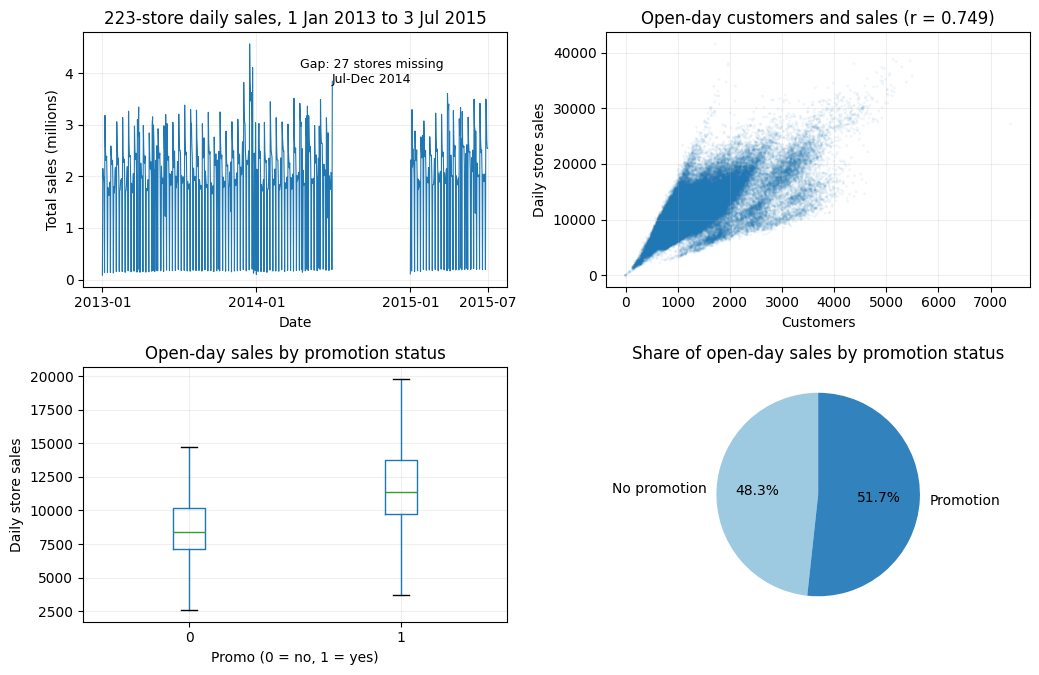

In [6]:
daily_portfolio = development_data.groupby("Date").agg(
    TotalSales=("Sales", "sum"), ObservedStores=("Store", "nunique")
).reindex(pd.date_range(development_data["Date"].min(), ranking_end))
# Compare the same six months using only complete portfolio dates.
first_half = daily_portfolio.loc[
    daily_portfolio.index.month <= 6
].query("ObservedStores == @top_store_count")
half_year_summary = first_half.groupby(first_half.index.year)["TotalSales"].agg(
    Days="count", Mean_daily_sales="mean")
display(half_year_summary.rename_axis("Jan-Jun year").round(0))
plot_sales = daily_portfolio["TotalSales"].copy()
# Keep calendar gaps visible; never replace missing sales with zero.
plot_sales.loc[daily_portfolio["ObservedStores"].ne(len(top_store_ids))] = float("nan")

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.0))
axes[0, 0].plot(plot_sales.index, plot_sales / 1_000_000,
                color="#1f77b4", linewidth=0.8)
axes[0, 0].set(title="223-store daily sales, 1 Jan 2013 to 3 Jul 2015",
               xlabel="Date", ylabel="Total sales (millions)")
axes[0, 0].text(pd.Timestamp("2014-10-01"), 3.8,
                "Gap: 27 stores missing\nJul-Dec 2014", ha="center", fontsize=9)
date_ticks = [daily_portfolio.index[0], pd.Timestamp("2014-01-01"),
              pd.Timestamp("2015-01-01"), ranking_end]
axes[0, 0].set_xticks(date_ticks, [date.strftime("%Y-%m") for date in date_ticks], rotation=0)

axes[0, 1].scatter(open_development["Customers"], open_development["Sales"],
                   s=4, alpha=0.07, color="#1f77b4", edgecolors="none")
axes[0, 1].set(title=f"Open-day customers and sales (r = {customer_sales_correlation:.3f})",
               xlabel="Customers", ylabel="Daily store sales")

open_development.boxplot(column="Sales", by="Promo", ax=axes[1, 0],
                         grid=False, showfliers=False)
axes[1, 0].set(title="Open-day sales by promotion status",
               xlabel="Promo (0 = no, 1 = yes)", ylabel="Daily store sales")

promotion_sales = open_development.groupby("Promo")["Sales"].sum().reindex([0, 1])
axes[1, 1].pie(promotion_sales, labels=["No promotion", "Promotion"],
               autopct="%1.1f%%", startangle=90, colors=["#9ecae1", "#3182bd"])
axes[1, 1].set_title("Share of open-day sales by promotion status")
for ax in axes.flat[:3]:
    ax.grid(alpha=0.2)
fig.suptitle("")
plt.tight_layout()
plt.show()

The time-series panel in Figure 1 uses 730 complete portfolio dates; the July-December 2014 gap reflects 27 missing stores, not a sales fall. For the same 223 stores, each January-June period has 181 complete days, including closures. Mean daily sales rose from 1.863 million in 2013 to 1.911 million in 2014 (+2.6%) and 1.984 million in 2015 (+3.8%). This comparable-period increase does not establish a continuous trend or its cause: weekday, opening and promotion patterns may differ. Selection by 2015 sales also limits generalisation. The weekly pattern supports the weekday baseline; the year-to-year change cautions that its historical means may become outdated.

Among open-store records, mean sales were 12,178.2 during promotion and 9,079.6 without promotion, an observed difference of about 34%. The pie chart's 51.7% promotional sales share also depends on the number of promotional store-days and cannot measure incremental sales caused by promotion. Public-holiday groups contain few open-store records. The boxplot hides outlier markers without deleting data. All comparisons are observational associations.

The correlation table includes all recorded days, including closures; the scatter uses open days only. Their Customers-Sales correlations are 0.859 and 0.749 respectively. Closed days can strengthen the pooled association through simultaneous zeros. Weekday is a cyclic category, so its differences are described by grouped means and later category indicators, without treating codes 1-7 as a continuous scale.

### 4.3 Forecasting decisions and EDA conclusion

| Variable | Decision for the later model |
|---|---|
| `DayOfWeek` | Use as a calendar predictor |
| `Open`, `Promo`, `StateHoliday`, `SchoolHoliday` | Aggregate to daily counts across the selected stores |
| `Customers` | Exclude because future customer counts are unavailable |
| `Date` | Order and split observations; add elapsed time in the Trend extension |
| `Store` | Use for top-store selection, then aggregate by date |

The Customers-Sales association helps explain historical sales, but future customer counts are unavailable at the forecast origin. The model therefore uses known calendar and assumed planned-event information. The final 28 days are excluded from EDA and model fitting. Their previously inspected results are distinguished from development selection in Sections 5.6-5.7.

## 5. Forecast Modelling

### 5.1 Prepare daily inputs and the time split

Each modelling row represents all 223 selected stores on one date. The analysis retains dates with a record for every selected store, including closed-store records. Dates with incomplete coverage are excluded from modelling; their observed sales remain in the cleaned data. This prevents a smaller recorded portfolio from being treated as the full sales target.

Inputs are weekday (1 = Monday, 7 = Sunday) and daily counts of stores marked open, on promotion, on a public holiday or on a school holiday. For this historical forecast exercise, opening and promotion records are assumed to represent plans available on 3 July 2015; holiday calendars are assumed known. Unexpected changes to those plans would affect real forecasts. `Customers` is excluded. Evaluation sales are reserved for later scoring.

In [7]:
# Aggregate schedule fields without evaluation sales or customer counts.
schedule = top_stores[[
    "Date", "Store", "Open", "Promo", "StateHoliday", "SchoolHoliday"
]].copy()
schedule["StateHolidayFlag"] = schedule["StateHoliday"].ne("0").astype(int)
daily_inputs = schedule.groupby("Date").agg(
    ObservedStores=("Store", "nunique"), OpenStores=("Open", "sum"),
    PromoStores=("Promo", "sum"), StateHolidayStores=("StateHolidayFlag", "sum"),
    SchoolHolidayStores=("SchoolHoliday", "sum")
).sort_index()
daily_inputs["DayOfWeek"] = daily_inputs.index.dayofweek + 1

# Zero below means no recorded stores; it does not impute sales.
calendar = pd.date_range(top_stores["Date"].min(), evaluation_end, name="Date")
coverage = daily_inputs["ObservedStores"].reindex(calendar, fill_value=0)
complete_dates = coverage[coverage.eq(len(top_store_ids))].index
excluded_dates = coverage[coverage.lt(len(top_store_ids))].index
assert coverage.loc[evaluation_start:evaluation_end].eq(len(top_store_ids)).all()

feature_columns = [
    "DayOfWeek", "OpenStores", "PromoStores", "StateHolidayStores", "SchoolHolidayStores"
]
complete_inputs = daily_inputs.loc[complete_dates, feature_columns]
X_train = complete_inputs.loc[:ranking_end].copy()
X_eval = complete_inputs.loc[evaluation_start:evaluation_end].copy()
# Training targets come exclusively from pre-evaluation observations.
training_sales = development_data.groupby("Date")["Sales"].sum()
y_train = training_sales.loc[X_train.index].rename("TotalSales")

assert X_train.index.is_unique and X_eval.index.is_unique
assert X_train.index.max() < X_eval.index.min()
assert X_eval.index.equals(pd.date_range(evaluation_start, evaluation_end))
assert X_train.index.equals(y_train.index)
assert X_train.notna().all().all() and X_eval.notna().all().all()
assert y_train.notna().all() and y_train.ge(0).all()
assert "Customers" not in feature_columns and "TotalSales" not in feature_columns

modelling_checks = pd.DataFrame({
    "Sample": ["Training inputs + target", "Evaluation inputs", "Excluded dates"],
    "First date": [X_train.index.min().date(), X_eval.index.min().date(),
                   excluded_dates.min().date()],
    "Last date": [X_train.index.max().date(), X_eval.index.max().date(),
                  excluded_dates.max().date()],
    "Days": [len(X_train), len(X_eval), len(excluded_dates)],
    "Recorded stores/day": [int(coverage.loc[X_train.index].min()),
                           int(coverage.loc[X_eval.index].min()),
                           int(coverage.loc[excluded_dates].min())],
}).set_index("Sample")
modelling_checks

,First date,Last date,Days,Recorded stores/day
Sample,,,,
Training inputs + target,2013-01-01,2015-07-03,730,223
Evaluation inputs,2015-07-04,2015-07-31,28,223
Excluded dates,2014-07-01,2014-12-31,184,196


The main model uses **730 complete training days**: January 2013-June 2014 and January-3 July 2015. Each of the **28 evaluation days** contains 223 stores. The 184 excluded dates in July-December 2014 contain only 196 stores, limiting seasonal evidence. Store-level EDA retains available records; portfolio curves and models require full coverage.

Both reference methods use identical daily targets and dates, without row caps or random subsampling. July sales do not enter fitting.

### 5.2 Weekday-mean baseline

Each forecast is the mean combined sales of complete training dates with the same weekday, with equal weight per date. The seven training-only means capture weekly patterns but ignore promotions, unusual openings, holidays and longer-term changes.

In [8]:
weekday_means = y_train.groupby(X_train["DayOfWeek"]).mean()
assert weekday_means.index.tolist() == list(range(1, 8))
baseline_train = X_train["DayOfWeek"].map(weekday_means)
baseline_eval = X_eval["DayOfWeek"].map(weekday_means)
assert baseline_train.notna().all() and baseline_eval.notna().all()

baseline_summary = pd.DataFrame({
    "Training days": y_train.groupby(X_train["DayOfWeek"]).count(),
    "Mean total sales": weekday_means
})
baseline_summary.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
baseline_summary.index.name = "Weekday"
baseline_summary.round(0)

,Training days,Mean total sales
Weekday,,
Mon,104,"2,550,135.000"
Tue,104,"2,308,895.000"
Wed,104,"2,181,232.000"
Thu,105,"2,057,467.000"
Fri,105,"2,241,344.000"
Sat,104,"2,043,762.000"
Sun,104,"171,666.000"


### 5.3 Multiple linear regression

The model is **predicted sales = intercept + weekday adjustment + opening term + promotion term + public-holiday term + school-holiday term**. Four store-count predictors and six weekday indicators give ten inputs; Monday is the reference weekday. Ordinary least squares minimises squared training errors, and the fitted model stays fixed throughout the 28-day horizon.

All five source fields vary in training. Opening count and the Sunday indicator are correlated (-0.890); both remain because weekday and opening coverage convey distinct information, but individual coefficients require caution. This is the reference specification used in Sections 5.4-5.5; Section 5.6 evaluates bounded extensions.

In [9]:
from sklearn.linear_model import LinearRegression

X_reg_train = pd.get_dummies(
    X_train, columns=["DayOfWeek"], drop_first=True, dtype=int
)
X_reg_eval = pd.get_dummies(
    X_eval, columns=["DayOfWeek"], drop_first=True, dtype=int
).reindex(columns=X_reg_train.columns, fill_value=0)
assert X_reg_train.nunique().gt(1).all()
assert X_reg_eval.columns.equals(X_reg_train.columns)
assert X_reg_train.index.equals(y_train.index) and X_reg_train.shape[1] == 10
feature_correlations = X_reg_train.corr()
print("Training correlation, OpenStores and Sunday:",
      round(feature_correlations.loc["OpenStores", "DayOfWeek_7"], 3))
print("Training PromoStores levels:", sorted(X_train["PromoStores"].unique().tolist()))

linear_model = LinearRegression()
linear_model.fit(X_reg_train, y_train)
linear_train = pd.Series(linear_model.predict(X_reg_train), index=X_train.index)
linear_eval = pd.Series(linear_model.predict(X_reg_eval), index=X_eval.index)
coefficients = pd.Series(linear_model.coef_, index=X_reg_train.columns)
coefficient_table = pd.concat([
    pd.Series({"Intercept": linear_model.intercept_}), coefficients
]).to_frame("Sales units per input unit")
coefficient_table.round(1)

Training correlation, OpenStores and Sunday: -0.89
Training PromoStores levels: [0, 223]


,Sales units per input unit
Intercept,"-1,797,042.500"
OpenStores,"18,222.300"
PromoStores,"3,130.200"
StateHolidayStores,"7,446.700"
SchoolHolidayStores,"1,029.000"
DayOfWeek_2,"-342,345.600"
DayOfWeek_3,"-426,481.100"
DayOfWeek_4,"-433,294.300"
DayOfWeek_5,"-340,940.100"
DayOfWeek_6,"-218,490.200"


### 5.4 Evaluate the fixed 28-day forecasts

Following the full-dataset quality audit, evaluation-period sales are used only for scoring after both sets of predictions are generated. **MAE** is the mean absolute daily error; **RMSE** is the square root of the mean squared daily error and penalises large misses. Lower is better for both. **R-squared** compares squared error with predicting the actual sample mean; it is not percentage accuracy and can be negative. Training scores describe fit, while held-out scores provide the forecast comparison. The separate four-week total error is **100 x (predicted total - actual total) / actual total**: positive means overforecasting. Small total error can hide offsetting daily errors.

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train_predictions = pd.DataFrame({"Baseline": baseline_train, "Regression": linear_train})
eval_predictions = pd.DataFrame({"Baseline": baseline_eval, "Regression": linear_eval})
assert eval_predictions.index.equals(X_eval.index)
assert train_predictions.index.equals(y_train.index)
assert train_predictions.shape == (len(X_train), 2)
assert eval_predictions.shape == (forecast_days, 2)
assert train_predictions.notna().all().all() and eval_predictions.notna().all().all()

evaluation_rows = top_stores[top_stores["Date"].between(evaluation_start, evaluation_end)]
y_eval = evaluation_rows.groupby("Date")["Sales"].sum().loc[X_eval.index]
assert y_eval.index.equals(eval_predictions.index) and y_eval.notna().all()
score_rows = []
for sample, actual, predictions in [
    ("Training", y_train, train_predictions), ("28-day evaluation", y_eval, eval_predictions)
]:
    for model in predictions:
        predicted = predictions[model]
        score_rows.append({
            "Sample": sample, "Model": model, "Days": len(actual),
            "MAE": mean_absolute_error(actual, predicted),
            "RMSE": mean_squared_error(actual, predicted) ** 0.5,
            "R-squared": r2_score(actual, predicted)
        })
scores = pd.DataFrame(score_rows).set_index(["Sample", "Model"])
scores.round({"MAE": 0, "RMSE": 0, "R-squared": 3})

Days         MAE        RMSE  R-squared
Sample            Model                                              
Training          Baseline     730 352,235.000 540,185.000      0.650
                  Regression   730 175,662.000 260,405.000      0.919
28-day evaluation Baseline      28 264,217.000 333,843.000      0.838
                  Regression    28 109,611.000 141,682.000      0.971

In [11]:
actual_total = y_eval.sum()
revenue_comparison = pd.DataFrame({
    "Predicted total": eval_predictions.sum(),
    "Total error": eval_predictions.sum() - actual_total,
    "Total error (%)": 100 * (eval_predictions.sum() - actual_total) / actual_total
})
print(f"Actual 28-day sales: {actual_total:,.0f}")
display(revenue_comparison.round({"Predicted total": 0, "Total error": 0,
                                  "Total error (%)": 2}))
# Check regression outputs without clipping values or changing either model.
diagnostic_rows = []
for sample, predictions, inputs in [
    ("Training fit", linear_train, X_train), ("Evaluation", linear_eval, X_eval)
]:
    negative = predictions.lt(0)
    holiday = inputs["StateHolidayStores"].gt(0)
    diagnostic_rows.append([sample, len(predictions), int(negative.sum()),
                            int(holiday.sum()), int((negative & holiday).sum())])
display(pd.DataFrame(diagnostic_rows, columns=[
    "Sample", "Days", "Negative", "Holiday days", "Negative on holidays"
]).set_index("Sample"))

forecast_results = eval_predictions.copy()
forecast_results["Actual"] = y_eval
daily_errors = eval_predictions.sub(y_eval, axis=0)
worst_date = daily_errors["Regression"].abs().idxmax()
print(f"Largest regression daily miss: {worst_date.date()}, "
      f"actual {y_eval.loc[worst_date]:,.0f}, "
      f"predicted {linear_eval.loc[worst_date]:,.0f}")

Actual 28-day sales: 56,542,356


,Predicted total,Total error,Total error (%)
Baseline,"54,218,001.000","-2,324,355.000",-4.110
Regression,"57,332,637.000","790,281.000",1.400


,Days,Negative,Holiday days,Negative on holidays
Sample,,,,
Training fit,730,9,31,9
Evaluation,28,0,0,0


Largest regression daily miss: 2015-07-17, actual 2,342,730, predicted 2,729,186


### 5.5 Forecast pattern and interpretation

Figure 2 displays all 28 portfolio-level forecasts alongside the actual sales from the same selected stores. It makes daily misses visible even when they cancel in the four-week total.

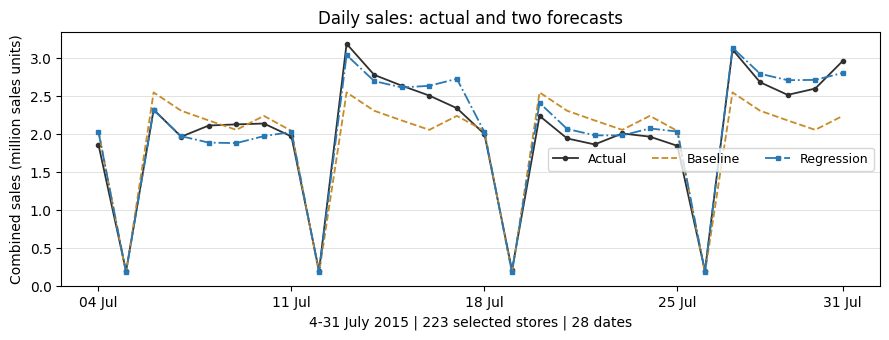

In [12]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for name, color, style, marker in [
    ("Actual", "#303030", "-", "o"),
    ("Baseline", "#c88b26", "--", None),
    ("Regression", "#2878b5", "-.", "s")
]:
    ax.plot(forecast_results.index, forecast_results[name] / 1_000_000,
            label=name, color=color, linestyle=style, marker=marker,
            markersize=3, linewidth=1.3)
ax.set(title="Daily sales: actual and two forecasts",
       xlabel="4-31 July 2015 | 223 selected stores | 28 dates",
       ylabel="Combined sales (million sales units)", ylim=(0, None))
ticks = forecast_results.index[[0, 7, 14, 21, 27]]
ax.set_xticks(ticks, [d.strftime("%d Jul") for d in ticks])
ax.grid(axis="y", color="#dddddd", linewidth=0.6)
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

**Weekday errors.** MAE measures daily error size; mean error (predicted minus actual) indicates direction. Each weekday has four July observations. This descriptive table does not refit the reference model.

In [13]:
weekday_errors = pd.DataFrame({
    "Weekday": X_eval["DayOfWeek"],
    "Absolute_error": daily_errors["Regression"].abs(),
    "Error": daily_errors["Regression"]
}).groupby("Weekday").agg(
    Days=("Error", "count"), MAE=("Absolute_error", "mean"),
    Mean_error=("Error", "mean")
)
weekday_errors.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekday_errors.round(0)

,Days,MAE,Mean_error
Mon,4,"87,483.000","9,610.000"
Tue,4,"81,180.000","40,319.000"
Wed,4,"140,432.000","16,227.000"
Thu,4,"128,886.000","-7,646.000"
Fri,4,"204,341.000","42,910.000"
Sat,4,"110,552.000","110,552.000"
Sun,4,"14,401.000","-14,401.000"


**Forecast performance.** Regression reduced held-out MAE by 58.5% and RMSE by 57.6% relative to the weekday baseline. R-squared was 0.971, not 97.1% forecast accuracy. Lower evaluation error may relate to the short July sample and its composition; one window cannot establish the cause or long-term performance. The largest regression miss was 17 July: 2,729,186 predicted against 2,342,730 actual, an overforecast of 386,456.

**Non-negative sales check.** Regression produced 9 negative fitted values across 730 training days, all on public holidays. Unconstrained linear regression permits negative outputs, which are impossible for sales and reveal poor fit on these dates. These are training fits; the 28 evaluation forecasts are non-negative, but contain no public holidays. July scores therefore cannot establish holiday reliability. The reference-model scores use raw predictions; Section 5.8 evaluates a zero floor separately without changing them.

Friday MAE was 204,341, compared with 14,401 on Sundays. Sunday's much smaller sales limit comparisons of relative accuracy using these absolute errors. All four Saturdays were overforecast (mean error and MAE both 110,552). These results identify dates for review, but four observations per weekday cannot establish persistent patterns or causes. The reference model is unchanged; Sections 5.6-5.7 report subsequent extensions.

**What the coefficients mean.** With other inputs fixed, Tuesday is predicted 342,346 sales units below Monday. Promotion count varies only between 0 and 223: its implied all-store contrast is about 698,000 units; a one-store change lacks empirical support. The positive Sunday term partly offsets fewer open stores and does not imply high Sunday sales. Correlated inputs complicate the positive public-holiday coefficient. The negative intercept describes an unobserved all-zero-input Monday. Coefficients express conditional associations; their raw magnitudes cannot establish variable importance or causal effects.

### 5.6 Bounded model comparison and chronological validation

**Development ranking rule:** lowest mean daily MAE across three equal-length development windows, with mean RMSE breaking an exact tie. This ranks candidates for further testing; it is not an operational deployment rule. Mean/worst absolute four-week total percentage error and negative forecasts are separate risk checks. No acceptable-error threshold is assumed.

Compare Baseline, Regression, Trend (Regression plus elapsed years since 1 January 2013), and Ridge (original inputs, squared-coefficient penalty, fixed alpha=1) [2]. Trend tests gradual change; Ridge tests shrinkage for correlated inputs. Standardisation uses training means and standard deviations only [3]. Alpha is not tuned; ranked predictions remain raw, and no feature search is used. A separate zero-floor sensitivity check appears in Section 5.8.

The windows are 11 April-8 May, 9 May-5 June and 6 June-3 July 2015. At each origin, reselect 223 stores using 2015 sales through the preceding day, breaking ties by Store ID. Fit on all earlier complete portfolio dates (646, 674 and 702 days) and predict exactly 28 consecutive complete days, assuming advance schedules. Changing portfolios mean this evaluates the selection-and-forecasting procedure.

The three development windows and July were inspected before this extension; two supplemental windows were added later. The three original windows support development selection; July is a previously inspected reference check, never a fresh independent test. Overlapping training histories and limited seasons restrict generalisation.

In [14]:
def backtest_window(start):
    """Compare fixed models using information available before a forecast origin.

    start: pandas Timestamp for a complete 28-day window in 2015.
    Returns score dictionaries, daily diagnostics and earlier holiday records.
    Uses train_clean and the declared feature/ranking settings; schedules are
    assumed known. Missing portfolio dates are excluded, never filled with zero.
    """
    end = start + pd.Timedelta(days=27)
    prior = train_clean[train_clean["Date"].between(ranking_start, start - pd.Timedelta(days=1))]
    counts = prior.groupby("Store")["Date"].nunique()
    assert len(counts) == len(store_ranking) and counts.eq((start - ranking_start).days).all()
    ranks = prior.groupby("Store")["Sales"].sum().sort_index().sort_values(
        ascending=False, kind="stable")
    ids = ranks.head(top_store_count).index
    rows = train_clean[train_clean["Store"].isin(ids) & train_clean["Date"].le(end)].copy()
    rows["Holiday"] = rows["StateHoliday"].ne("0").astype(int)
    daily = rows.groupby("Date").agg(
        Stores=("Store", "nunique"), Sales=("Sales", "sum"),
        OpenStores=("Open", "sum"), PromoStores=("Promo", "sum"),
        StateHolidayStores=("Holiday", "sum"), SchoolHolidayStores=("SchoolHoliday", "sum"))
    daily["DayOfWeek"] = daily.index.dayofweek + 1
    daily = daily[daily["Stores"].eq(top_store_count)]
    past, future = daily[daily.index < start], daily.loc[start:end]
    assert past.index.max() < start and future.index.equals(pd.date_range(start, end))
    train_x = pd.get_dummies(past[feature_columns], columns=["DayOfWeek"], drop_first=True, dtype=int)
    test_x = pd.get_dummies(future[feature_columns], columns=["DayOfWeek"], drop_first=True, dtype=int)
    test_x = test_x.reindex(columns=train_x.columns, fill_value=0)
    assert train_x.shape[1] == 10 and train_x.notna().all().all() and test_x.notna().all().all()
    weekday_mean = past.groupby("DayOfWeek")["Sales"].mean()
    trend_train, trend_test = train_x.copy(), test_x.copy()
    trend_train["Time"] = (past.index - train_clean["Date"].min()).days / 365.25
    trend_test["Time"] = (future.index - train_clean["Date"].min()).days / 365.25
    # Learn scaling from past observations only, then reuse it for the future.
    centre, scale = train_x.mean(), train_x.std(ddof=0).replace(0, 1)
    ridge = Ridge(alpha=1.0).fit((train_x - centre) / scale, past["Sales"])
    predictions = pd.DataFrame({
        "Baseline": future["DayOfWeek"].map(weekday_mean),
        "Regression": LinearRegression().fit(train_x, past["Sales"]).predict(test_x),
        "Trend": LinearRegression().fit(trend_train, past["Sales"]).predict(trend_test),
        "Ridge": ridge.predict((test_x - centre) / scale)
    }, index=future.index)
    assert predictions.notna().all().all()
    actual, holiday = future["Sales"], future["StateHolidayStores"].gt(0)
    result = []
    for model in predictions:
        error = predictions[model] - actual
        result.append({
            "Window": start.strftime("%d %b") + "-" + end.strftime("%d %b"),
            "Model": model, "Train days": len(past), "H-days": int(holiday.sum()),
            "MAE": error.abs().mean(), "RMSE": (error.pow(2).mean()) ** 0.5,
            "Total %": 100 * error.sum() / actual.sum(),
            "H-MAE": error[holiday].abs().mean(), "Neg": int(predictions[model].lt(0).sum())
        })
    return result, future.join(predictions), past[past["StateHolidayStores"].gt(0)]

In [15]:
from sklearn.linear_model import Ridge

# Three fixed development windows; no alpha search or feature search.
backtest_starts = [evaluation_start - pd.Timedelta(days=28 * k) for k in [3, 2, 1]]
backtest_rows, backtest_details, holiday_history = [], {}, {}
for start in backtest_starts:
    rows, details, holidays = backtest_window(start)
    backtest_rows.extend(rows)
    backtest_details[start], holiday_history[start] = details, holidays
backtest_scores = pd.DataFrame(backtest_rows).set_index(["Window", "Model"])
selection_table = backtest_scores.groupby("Model").agg(
    Mean_MAE=("MAE", "mean"), Mean_RMSE=("RMSE", "mean"),
    Mean_abs_total_pct=("Total %", lambda x: x.abs().mean()),
    Worst_abs_total_pct=("Total %", lambda x: x.abs().max()), Neg=("Neg", "sum"))
selection_table = selection_table.sort_values(["Mean_MAE", "Mean_RMSE"])
selected_model = selection_table.index[0]
display(selection_table.round(2))
# Show every development window, rather than only the average or best window.
display(backtest_scores["MAE"].unstack("Model").reindex(
    [s.strftime("%d %b") + "-" + (s + pd.Timedelta(days=27)).strftime("%d %b")
     for s in backtest_starts]).round(0))

,Mean_MAE,Mean_RMSE,Mean_abs_total_pct,Worst_abs_total_pct,Neg
Model,,,,,
Trend,"161,659.220","223,369.200",2.100,5.370,1
Regression,"164,256.430","246,373.110",5.620,8.990,1
Ridge,"166,285.310","249,400.350",5.900,9.440,1
Baseline,"397,692.660","573,664.130",5.130,7.680,0


Model,Baseline,Regression,Ridge,Trend
Window,,,,
11 Apr-08 May,"439,292.000","144,012.000","146,999.000","154,792.000"
09 May-05 Jun,"447,261.000","218,307.000","218,655.000","193,150.000"
06 Jun-03 Jul,"306,525.000","130,451.000","133,202.000","137,036.000"


**Original four-procedure result.** Trend ranks first within this original comparison: mean MAE is 161,659 versus 164,256 for Regression, a 1.6% reduction. It improves only one of three windows. Its mean absolute four-week total error is 2.10%, compared with 5.62% for Regression; Ridge has worse mean MAE (166,285). These are descriptive differences across three windows, without evidence of a statistically reliable improvement. Trend leads this four-procedure stage; Section 5.10 reports the final seven-procedure ranking. No model is approved for operational use. Sections 5.2-5.5 retain the original regression as the comparison reference and report its unaltered July results.

### 5.7 Holiday diagnosis and previously inspected July check

Compare the original model's negative forecast on 14 May and all four development holiday dates. Then score July without changing the development selection rule; July's original-model results were already known.

In [16]:
# Diagnose the original regression's negative out-of-sample forecast.
diagnosis_start, diagnosis_date = pd.Timestamp("2015-05-09"), pd.Timestamp("2015-05-14")
case = backtest_details[diagnosis_start].loc[diagnosis_date]
history = holiday_history[diagnosis_start]
print("14 May inputs:", case[["OpenStores", "PromoStores", "StateHolidayStores"]].to_dict())
print("Earlier holiday days:", len(history), "| Open-store range:",
      int(history["OpenStores"].min()), int(history["OpenStores"].max()))
same_schedule = history[feature_columns].eq(
    case[feature_columns]).all(axis=1)
print("Earlier holidays matching all five model inputs:", int(same_schedule.sum()))
holiday_errors = pd.concat([
    frame.loc[frame["StateHolidayStores"].gt(0), ["Sales", "Regression", "Trend", "Ridge"]]
    for frame in backtest_details.values()])
holiday_diagnosis = pd.DataFrame({
    "14 May prediction": case[["Regression", "Trend", "Ridge"]],
    "14 May actual": case["Sales"],
    "Holiday MAE (4 days)": holiday_errors.drop(columns="Sales").sub(
        holiday_errors["Sales"], axis=0).abs().mean(),
    "Negative holiday forecasts": holiday_errors.drop(columns="Sales").lt(0).sum()
})
display(holiday_diagnosis.round(0))
# July is a previously inspected reference period; it does not choose the winner.
july_rows, july_details, _ = backtest_window(evaluation_start)
july_comparison = pd.DataFrame(july_rows).set_index("Model")
assert (july_details["Regression"] - linear_eval).abs().max() < 0.01
assert (july_details["Baseline"] - baseline_eval).abs().max() < 0.01
print("Development-selected model:", selected_model)
display(july_comparison[["MAE", "RMSE", "Total %", "Neg"]].round(2))

14 May inputs: {'OpenStores': 16.0, 'PromoStores': 0.0, 'StateHolidayStores': 223.0}
Earlier holiday days: 28 | Open-store range: 13 211
Earlier holidays matching all five model inputs: 1


,14 May prediction,14 May actual,Holiday MAE (4 days),Negative holiday forecasts
Regression,"-284,718.000","219,056.000","240,352.000",1
Trend,"-222,648.000","219,056.000","239,816.000",1
Ridge,"-289,456.000","219,056.000","227,190.000",1


Development-selected model: Trend


,MAE,RMSE,Total %,Neg
Model,,,,
Baseline,"264,217.430","333,842.810",-4.110,0
Regression,"109,610.700","141,681.980",1.400,0
Trend,"159,900.000","190,689.380",6.330,0
Ridge,"112,162.210","143,760.010",1.520,0


On 14 May, 16 stores were open, none were on promotion and all 223 were marked as on a public holiday; actual sales were 219,056. The 28 earlier holiday dates include one with identical values for all five inputs. Unseen inputs alone therefore cannot explain the negative prediction. An unconstrained additive model can fail even at a represented setting; this check does not identify a unique cause. Every regression variant produces one negative holiday forecast. Four holiday observations cannot establish reliability.

Trend ranks first in development but performs worse in the previously inspected July period: MAE 159,900 versus 109,611 and total error +6.33% versus +1.40% for Regression. Its 60.12 million forecast exceeds 56.54 million actual sales. July raises concern about stability, but it cannot be reused as an independent test to declare Regression the winner. Trend leads the original four-procedure comparison; Section 5.10 supplies the completed ranking. Regression remains an interpretable reference. Neither is approved for operational use without genuinely unseen validation, especially on holidays.

### 5.8 Supplemental historical and non-negative sensitivity checks

The model specifications and original three-window selection rule above stay fixed. Two additional, non-overlapping 28-day windows (14 February-13 March and 14 March-10 April 2015) check earlier-period behaviour; they are **supplemental development evidence**, not an untouched final test or a reason to rerank the models. The same past-only store selection and feature rules apply. For the holiday failure, the sensitivity check compares raw regression-family forecasts with a predeclared zero floor across these two windows, the original three windows and July. The analysis report daily MAE, holiday versus other-day MAE, total error and the number of changed predictions. No result is hidden when the rule has no effect.


In [17]:
supplemental_starts = [pd.Timestamp('2015-02-14'), pd.Timestamp('2015-03-14')]
supplemental_rows, supplemental_details = [], {}
for start in supplemental_starts:
    rows, details, _ = backtest_window(start)
    supplemental_rows.extend(rows)
    supplemental_details[start] = details
supplemental_scores = pd.DataFrame(supplemental_rows).set_index(['Window', 'Model'])
display(supplemental_scores[['MAE', 'Total %', 'H-days']].round(2))

floor_rows = []
all_check_details = {**supplemental_details, **backtest_details,
                     evaluation_start: july_details}
for start, frame in sorted(all_check_details.items()):
    actual = frame['Sales']
    holiday = frame['StateHolidayStores'].gt(0)
    for model in ['Regression', 'Trend', 'Ridge']:
        raw = frame[model]
        floored = raw.clip(lower=0)
        floor_rows.append({
            'Window start': start.date(), 'Model': model,
            'Holiday days': int(holiday.sum()),
            'Negative predictions': int(raw.lt(0).sum()),
            'Raw MAE': (raw - actual).abs().mean(),
            'Floored MAE': (floored - actual).abs().mean(),
            'Raw holiday MAE': (raw[holiday] - actual[holiday]).abs().mean(),
            'Floored holiday MAE': (floored[holiday] - actual[holiday]).abs().mean(),
            'Raw other-day MAE': (raw[~holiday] - actual[~holiday]).abs().mean(),
            'Floored other-day MAE': (floored[~holiday] - actual[~holiday]).abs().mean(),
            'Raw total error %': 100 * (raw - actual).sum() / actual.sum(),
            'Floored total error %': 100 * (floored - actual).sum() / actual.sum(),
        })
floor_comparison = pd.DataFrame(floor_rows).set_index(['Window start', 'Model'])
assert floor_comparison['Negative predictions'].sum() == 3
display(floor_comparison.loc[(slice(None), 'Regression'),
    ['Holiday days', 'Negative predictions', 'Raw MAE', 'Floored MAE',
     'Raw holiday MAE', 'Floored holiday MAE',
     'Raw total error %', 'Floored total error %']].round(2))


MAE  Total %  H-days
Window        Model                                  
14 Feb-13 Mar Baseline   249,242.290   -1.370       0
              Regression 132,429.130   -1.070       0
              Trend      138,372.850    2.530       0
              Ridge      131,667.790   -0.340       0
14 Mar-10 Apr Baseline   495,252.690   -2.730       2
              Regression 209,118.590   -5.670       2
              Trend      206,384.060   -2.540       2
              Ridge      211,950.090   -5.820       2

,,Holiday days,Negative predictions,Raw MAE,Floored MAE,Raw holiday MAE,Floored holiday MAE,Raw total error %,Floored total error %
Window start,Model,,,,,,,,
2015-02-14,Regression,0,0,"132,429.130","132,429.130",NaN,NaN,-1.070,-1.070
2015-03-14,Regression,2,0,"209,118.590","209,118.590","339,589.610","339,589.610",-5.670,-5.670
2015-04-11,Regression,1,0,"144,011.530","144,011.530","245,857.270","245,857.270",-3.900,-3.900
2015-05-09,Regression,3,1,"218,307.190","208,138.690","238,517.140","143,611.120",-8.990,-8.470
2015-06-06,Regression,0,0,"130,450.570","130,450.570",NaN,NaN,-3.960,-3.960
2015-07-04,Regression,0,0,"109,610.700","109,610.700",NaN,NaN,1.400,1.400


**Supplemental result.** The original regression beats the weekday baseline on daily MAE in both new windows: 132,429 versus 249,242 for 14 February-13 March, and 209,119 versus 495,253 for 14 March-10 April. Trend is worse than the original regression in the first and only slightly better in the second; these checks do not establish a stable winner. The second window contains two public holidays and the original regression underforecasts its four-week total by 5.67%.

**Zero-floor sensitivity.** Across all six inspected windows, the floor changes one original-regression forecast, on 14 May. Its MAE in that 28-day window falls from 218,307 to 208,139; holiday-day MAE across the three holiday dates falls from 238,517 to 143,611. Non-holiday predictions are unchanged, while the four-week total error remains a substantial underforecast, moving from -8.99% to -8.47%. The floor prevents an impossible negative number; it does not establish reliable holiday or budget forecasts. These checks were added after earlier results had been inspected and therefore remain development evidence.


## 5.9 Decision tree and bounded parameter tuning

This later development extension tests a shallow regression tree against the same ten inputs and adjusts Ridge's penalty. The original four-model results remain visible. Tree depth is restricted to 2, 3 or 4 and minimum leaf size to 5 or 15 training dates; Ridge alpha is restricted to 0.01, 0.1, 1, 10 or 100. These grids are fixed before running this extension.

At each outer origin, store selection uses earlier sales only. Within that selected portfolio, parameters are chosen by mean MAE on up to two earlier complete 28-day blocks. Each inner fit and Ridge standardisation use dates before that block. Membership is fixed using the outer training history, so inner scores are tuning diagnostics, not independent portfolio-selection tests. Outer forecasts remain strictly chronological. The existing three-window mean-MAE rule ranks six candidate procedures; all inspected windows remain development evidence.

A self-contained Matplotlib heatmap displays training-input correlations.

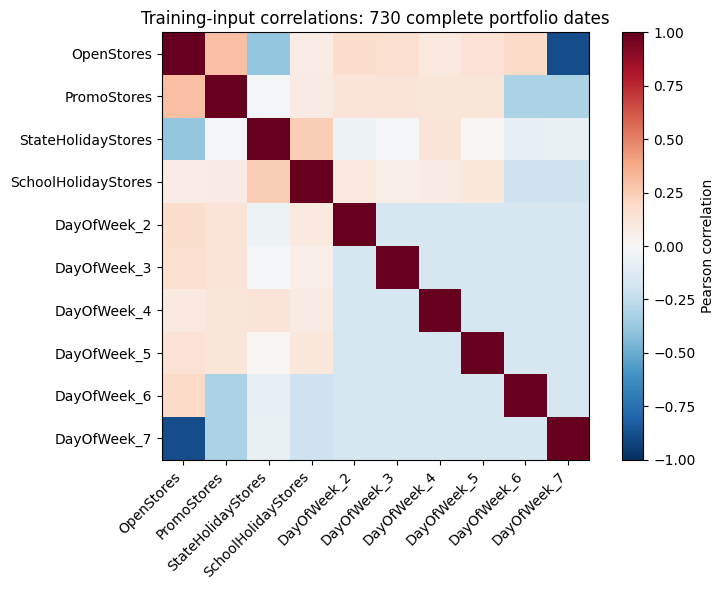

,Mean_MAE,Mean_RMSE,Mean_abs_total_pct,Worst_abs_total_pct,Neg
Model,,,,,
Trend,"161,659.220","223,369.200",2.100,5.370,1
Regression,"164,256.430","246,373.110",5.620,8.990,1
Tuned Ridge,"165,835.600","248,877.820",5.710,9.010,1
Ridge,"166,285.310","249,400.350",5.900,9.440,1
Tree,"197,203.400","302,425.090",5.530,10.260,0
Baseline,"397,692.660","573,664.130",5.130,7.680,0


,Train days,Inner blocks,Depth,Leaf,Alpha
Origin,,,,,
2015-02-14,590,1,4,5,10.000
2015-03-14,618,2,4,15,10.000
2015-04-11,646,2,4,5,10.000
2015-05-09,674,2,2,15,0.010
2015-06-06,702,2,4,15,0.010
2015-07-04,730,2,4,5,0.010


,Train days,H-days,MAE,RMSE,Total %,H-MAE,Neg
Model,,,,,,,
Tree,730,0,"163,126.520","216,880.710",-2.090,NaN,0
Tuned Ridge,730,0,"109,745.190","141,783.780",1.400,NaN,0


,14 May prediction,Holiday MAE (4 days),Negative holiday forecasts
Tree,"170,035.080","336,541.830",0.000
Tuned Ridge,"-285,101.740","251,229.960",1.000


In [18]:
import sys
import numpy as np
from sklearn.tree import DecisionTreeRegressor

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(feature_correlations, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_correlations)), feature_correlations.columns, rotation=45, ha="right")
ax.set_yticks(range(len(feature_correlations)), feature_correlations.index)
fig.colorbar(image, ax=ax, label="Pearson correlation")
ax.set_title("Training-input correlations: 730 complete portfolio dates")
fig.tight_layout()
plt.show()


def extended_window(start, return_models=False):
    """Tune two bounded procedures and forecast a complete 28-day window.

    Parameters: start is a pandas Timestamp in 2015.
    Returns: scores, predictions, settings and grid scores; optional fitted
    artifacts (past, x, xf, tree) when return_models=True.
    Uses earlier outcomes only; fixed outer-portfolio membership is used in
    inner tuning. Future schedules are assumed known, as in the original model.
    """
    end = start + pd.Timedelta(days=27)
    prior = train_clean[train_clean.Date.between(ranking_start, start - pd.Timedelta(days=1))]
    ranks = prior.groupby("Store").Sales.sum().sort_index().sort_values(ascending=False, kind="stable")
    ids = ranks.head(top_store_count).index
    rows = train_clean[train_clean.Store.isin(ids) & train_clean.Date.le(end)].copy()
    rows["Holiday"] = rows.StateHoliday.ne("0").astype(int)
    daily = rows.groupby("Date").agg(Stores=("Store", "nunique"), Sales=("Sales", "sum"),
        OpenStores=("Open", "sum"), PromoStores=("Promo", "sum"),
        StateHolidayStores=("Holiday", "sum"), SchoolHolidayStores=("SchoolHoliday", "sum"))
    daily["DayOfWeek"] = daily.index.dayofweek + 1
    daily = daily[daily.Stores.eq(top_store_count)]
    past, future = daily[daily.index < start], daily.loc[start:end]
    assert future.index.equals(pd.date_range(start, end)) and past.index.max() < start
    x = pd.get_dummies(past[feature_columns], columns=["DayOfWeek"], drop_first=True, dtype=int)
    xf = pd.get_dummies(future[feature_columns], columns=["DayOfWeek"], drop_first=True, dtype=int)
    xf = xf.reindex(columns=x.columns, fill_value=0)
    assert x.shape[1] == 10 and x.notna().all().all() and xf.notna().all().all()
    candidates = [("Tree", d, leaf, None) for d in [2, 3, 4] for leaf in [5, 15]]
    candidates += [("Tuned Ridge", None, None, a) for a in [0.01, 0.1, 1.0, 10.0, 100.0]]
    grids = []
    for origin in [start - pd.Timedelta(days=56), start - pd.Timedelta(days=28)]:
        dates = pd.date_range(origin, periods=28)
        if not dates.isin(past.index).all():
            continue  # Incomplete portfolio dates are never imputed or shifted.
        fit = past.index < origin
        assert fit.sum() >= 365 and dates.max() < start
        centre, scale = x.loc[fit].mean(), x.loc[fit].std(ddof=0).replace(0, 1)
        for name, depth, leaf, alpha in candidates:
            if name == "Tree":
                model = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=leaf, random_state=0)
                model.fit(x.loc[fit], past.loc[fit, "Sales"])
                pred = model.predict(x.loc[dates])
            else:
                model = Ridge(alpha=alpha).fit((x.loc[fit] - centre) / scale, past.loc[fit, "Sales"])
                pred = model.predict((x.loc[dates] - centre) / scale)
            error = pred - past.loc[dates, "Sales"].to_numpy()
            grids.append({"Origin": start, "Inner start": origin, "Model": name,
                "Depth": depth, "Leaf": leaf, "Alpha": alpha,
                "MAE": np.abs(error).mean(), "RMSE": np.sqrt(np.mean(error ** 2))})
    grid = pd.DataFrame(grids)
    assert not grid.empty
    tree_grid = grid[grid.Model.eq("Tree")].groupby(["Depth", "Leaf"])[["MAE", "RMSE"]].mean().reset_index()
    # Exact metric ties favour the simpler tree: lower depth, then larger leaves.
    chosen = tree_grid.sort_values(["MAE", "RMSE", "Depth", "Leaf"], ascending=[True, True, True, False]).iloc[0]
    ridge_grid = grid[grid.Model.eq("Tuned Ridge")].groupby("Alpha")[["MAE", "RMSE"]].mean().reset_index()
    chosen_ridge = ridge_grid.sort_values(["MAE", "RMSE", "Alpha"], ascending=[True, True, False]).iloc[0]
    tree = DecisionTreeRegressor(max_depth=int(chosen.Depth), min_samples_leaf=int(chosen.Leaf), random_state=0)
    tree.fit(x, past.Sales)
    centre, scale = x.mean(), x.std(ddof=0).replace(0, 1)
    ridge = Ridge(alpha=float(chosen_ridge.Alpha)).fit((x - centre) / scale, past.Sales)
    prediction = pd.DataFrame({"Tree": tree.predict(xf),
        "Tuned Ridge": ridge.predict((xf - centre) / scale)}, index=future.index)
    assert prediction.notna().all().all() and prediction.Tree.ge(0).all()
    result = []
    for name in prediction:
        error = prediction[name] - future.Sales
        holiday = future.StateHolidayStores.gt(0)
        result.append({"Window": start.strftime("%d %b") + "-" + end.strftime("%d %b"),
            "Model": name, "Train days": len(past), "H-days": int(holiday.sum()),
            "MAE": error.abs().mean(), "RMSE": np.sqrt(error.pow(2).mean()),
            "Total %": 100 * error.sum() / future.Sales.sum(),
            "H-MAE": error[holiday].abs().mean(), "Neg": int(prediction[name].lt(0).sum())})
    settings = {"Origin": start, "Train days": len(past), "Inner blocks": grid["Inner start"].nunique(),
        "Depth": int(chosen.Depth), "Leaf": int(chosen.Leaf), "Alpha": float(chosen_ridge.Alpha)}
    output = (result, future.join(prediction), settings, grid)
    return output + ((past, x, xf, tree),) if return_models else output


extended_rows, tuning_rows, tuning_grids, extended_details = [], [], [], {}
extension_starts = sorted(set(backtest_starts + [pd.Timestamp("2015-02-14"), pd.Timestamp("2015-03-14"), evaluation_start]))
for start in extension_starts:
    result, detail, settings, grid = extended_window(start)
    # Independently reconcile portfolio, target and inputs with the original procedure.
    original_rows, original_detail, _ = backtest_window(start)
    pd.testing.assert_frame_equal(detail[original_detail.columns[:7]], original_detail.iloc[:, :7])
    extended_rows.extend(result)
    extended_details[start] = detail
    tuning_rows.append(settings)
    tuning_grids.append(grid)
extended_scores = pd.DataFrame(extended_rows).set_index(["Window", "Model"])
tuning_settings = pd.DataFrame(tuning_rows).set_index("Origin")
tuning_grid_scores = pd.concat(tuning_grids, ignore_index=True)
primary_labels = backtest_scores.index.get_level_values("Window").unique()
expanded_development = pd.concat([backtest_scores, extended_scores.loc[primary_labels]])
extended_selection = expanded_development.groupby("Model").agg(
    Mean_MAE=("MAE", "mean"), Mean_RMSE=("RMSE", "mean"),
    Mean_abs_total_pct=("Total %", lambda s: s.abs().mean()),
    Worst_abs_total_pct=("Total %", lambda s: s.abs().max()), Neg=("Neg", "sum"))
extended_selection = extended_selection.sort_values(["Mean_MAE", "Mean_RMSE"])
extended_selected_model = extended_selection.index[0]
july_label = evaluation_start.strftime("%d %b") + "-" + evaluation_end.strftime("%d %b")
extended_july = extended_scores.loc[july_label]
extended_holidays = pd.concat([v[v.StateHolidayStores.gt(0)] for k, v in extended_details.items() if k in backtest_starts])
extended_holiday_diagnosis = pd.DataFrame({name: {
    "14 May prediction": extended_holidays.loc[pd.Timestamp("2015-05-14"), name],
    "Holiday MAE (4 days)": (extended_holidays[name] - extended_holidays.Sales).abs().mean(),
    "Negative holiday forecasts": int(extended_holidays[name].lt(0).sum())}
    for name in ["Tree", "Tuned Ridge"]}).T
display(extended_selection.round(2))
display(tuning_settings)
display(extended_july.round(2))
display(extended_holiday_diagnosis.round(2))


The six-procedure stage retains **Trend** (mean MAE 161,659), followed by Regression (164,256), Tuned Ridge (165,836), fixed-alpha Ridge (166,285), Tree (197,203) and Baseline (397,693). Tree is 20.1% worse than Regression on average development MAE and beats it only in February among five historical windows. Its July MAE is 163,127, compared with Regression's 109,611. Tuning reduces Ridge's average development MAE by only 0.27% relative to alpha=1; it remains 0.96% above Regression.

The selected tree depths range from 2 to 4 and leaf minima from 5 to 15; penalties vary between 0.01 and 10 across origins. February has one complete inner block; later origins have two. The bounded grids are parameter-sensitivity checks, not exhaustive optimisation.

On 14 May, Tree forecasts 170,035 against actual sales of 219,056. It has no negative outer forecasts across all six inspected windows, but four-date development holiday MAE is 336,542 versus Regression's 240,352. Tuned Ridge still predicts -285,102 on 14 May. Feasible non-negative output alone does not resolve holiday accuracy. Within these six procedures, Trend is the development leader; Section 5.10 reports the completed seven-procedure comparison. These later-added procedures and all inspected periods are development evidence.

### 5.10 Tree interpretation and a fixed random forest comparison

The actual May tree and its 14 May path are inspected using plot_tree; node values are mean training sales. Depth diagnostics reuse existing inner-validation scores for the May and July origins. These displays do not change fitted parameters, ranking dates or predictions.

A single random forest checks whether averaging bounded trees improves the observed comparison. Before running it, we fix 100 trees, maximum depth 4, minimum leaf size 5, all ten features available for splitting, bootstrap sampling of half the training dates, and seed 0. Predictions average the trees' leaf means. No forest hyperparameters are searched. The same chronological outer training sets, schedules and 28-day outcomes are retained. The original three-window mean-MAE rule now ranks seven procedures. This later comparison remains development evidence, with no new independent test.

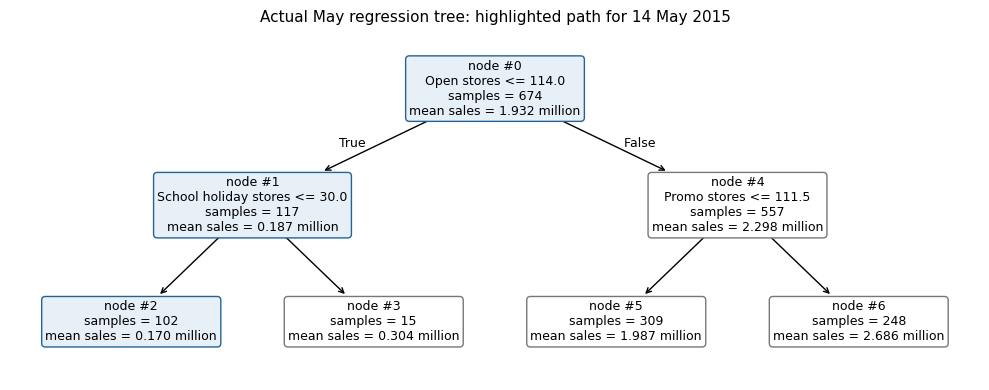

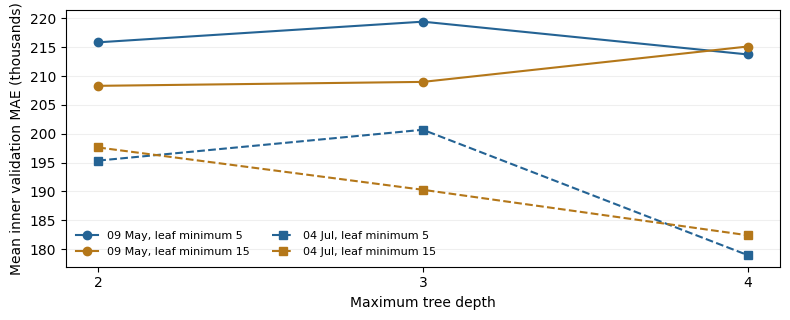

,Node,Decision,Training dates,Mean training sales
0,0,Open stores = 16 <= 114.0,674,"1,931,676.130"
1,1,School holiday stores = 8 <= 30.0,117,"187,225.430"
2,2,Leaf: mean training sales,102,"170,035.080"


,Training dates,Public holiday dates,Mean sales,Open stores minimum,Open stores maximum
0,102,7,"170,035.080",13,17


,Mean_MAE,Mean_RMSE,Mean_abs_total_pct,Worst_abs_total_pct,Neg
Model,,,,,
Forest,"160,117.920","255,617.380",4.870,7.890,0
Trend,"161,659.220","223,369.200",2.100,5.370,1
Regression,"164,256.430","246,373.110",5.620,8.990,1
Tuned Ridge,"165,835.600","248,877.820",5.710,9.010,1
Ridge,"166,285.310","249,400.350",5.900,9.440,1
Tree,"197,203.400","302,425.090",5.530,10.260,0
Baseline,"397,692.660","573,664.130",5.130,7.680,0


,,Train days,H-days,MAE,RMSE,Total %,H-MAE,Neg
Window,Model,,,,,,,
14 Feb-13 Mar,Forest,590,0,"112,357.990","167,552.560",-0.920,NaN,0
14 Mar-10 Apr,Forest,618,2,"205,562.200","315,278.740",-5.730,"59,773.980",0
11 Apr-08 May,Forest,646,1,"160,642.120","270,512.460",-3.600,"7,933.140",0
09 May-05 Jun,Forest,674,3,"192,319.620","264,460.370",-7.890,"61,615.140",0
06 Jun-03 Jul,Forest,702,0,"127,392.030","231,879.300",-3.110,NaN,0
04 Jul-31 Jul,Forest,730,0,"138,087.140","187,756.170",-1.070,NaN,0


,14 May prediction,Holiday MAE (4 days),Negative holiday forecasts
Forest,"212,781.800","48,194.640",0.000


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree

# Fixed before this new comparison; no search of forest settings or outer scores.
forest_specification = dict(n_estimators=100, max_depth=4,
    min_samples_leaf=5, max_features=1.0, bootstrap=True, max_samples=0.5,
    random_state=0, n_jobs=1)
forest_rows, forest_details, tree_artifacts = [], {}, {}
for start in extension_starts:
    _, detail, settings, _, artifacts = extended_window(start, return_models=True)
    past, x, xf, fitted_tree = artifacts
    forest = RandomForestRegressor(**forest_specification).fit(x, past.Sales)
    prediction = pd.Series(forest.predict(xf), index=detail.index, name="Forest")
    assert prediction.ge(0).all() and prediction.index.equals(detail.index)
    error, holiday = prediction - detail.Sales, detail.StateHolidayStores.gt(0)
    forest_rows.append({"Window": start.strftime("%d %b") + "-" +
        (start + pd.Timedelta(days=27)).strftime("%d %b"), "Model": "Forest",
        "Train days": len(past), "H-days": int(holiday.sum()),
        "MAE": error.abs().mean(), "RMSE": np.sqrt(error.pow(2).mean()),
        "Total %": 100 * error.sum() / detail.Sales.sum(),
        "H-MAE": error[holiday].abs().mean(), "Neg": int(prediction.lt(0).sum())})
    forest_details[start] = detail.join(prediction)
    tree_artifacts[start] = artifacts
forest_scores = pd.DataFrame(forest_rows).set_index(["Window", "Model"])
# The original July summary has additional columns; use the matched daily data
# to independently validate the forest comparison against all original methods.
for start, frame in forest_details.items():
    _, original, _ = backtest_window(start)
    pd.testing.assert_frame_equal(frame[original.columns[:7]], original.iloc[:, :7])
seven_development = pd.concat([expanded_development, forest_scores.loc[primary_labels]])
seven_selection = seven_development.groupby("Model").agg(
    Mean_MAE=("MAE", "mean"), Mean_RMSE=("RMSE", "mean"),
    Mean_abs_total_pct=("Total %", lambda s: s.abs().mean()),
    Worst_abs_total_pct=("Total %", lambda s: s.abs().max()), Neg=("Neg", "sum"))
seven_selection = seven_selection.sort_values(["Mean_MAE", "Mean_RMSE"])
seven_selected_model = seven_selection.index[0]
forest_july = forest_scores.loc[july_label]
forest_holidays = pd.concat([frame[frame.StateHolidayStores.gt(0)]
    for start, frame in forest_details.items() if start in backtest_starts])
forest_holiday_diagnosis = pd.DataFrame({"Forest": {
    "14 May prediction": forest_holidays.loc[pd.Timestamp("2015-05-14"), "Forest"],
    "Holiday MAE (4 days)": (forest_holidays.Forest - forest_holidays.Sales).abs().mean(),
    "Negative holiday forecasts": int(forest_holidays.Forest.lt(0).sum())}}).T

# Diagnose the actual, previously evaluated May tree. No display-only refit.
diagnostic_origin = pd.Timestamp("2015-05-09")
past, x, xf, diagnostic_tree = tree_artifacts[diagnostic_origin]
diagnostic_date = pd.Timestamp("2015-05-14")
case = xf.loc[[diagnostic_date]]
node_ids = diagnostic_tree.decision_path(case).indices
path_rows = []
readable_features = {"OpenStores": "Open stores", "PromoStores": "Promo stores",
    "StateHolidayStores": "Public holiday stores", "SchoolHolidayStores": "School holiday stores",
    **{f"DayOfWeek_{i}": day for i, day in zip(range(2, 8),
        ["Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])}}
for node in node_ids:
    feature = diagnostic_tree.tree_.feature[node]
    if feature >= 0:
        name = x.columns[feature]
        value, threshold = float(case.iloc[0, feature]), diagnostic_tree.tree_.threshold[node]
        decision = f"{readable_features[name]} = {value:g} {'<=' if value <= threshold else '>'} {threshold:.1f}"
    else:
        decision = "Leaf: mean training sales"
    path_rows.append({"Node": int(node), "Decision": decision,
        "Training dates": int(diagnostic_tree.tree_.n_node_samples[node]),
        "Mean training sales": float(diagnostic_tree.tree_.value[node, 0, 0])})
tree_path = pd.DataFrame(path_rows)
leaf = int(diagnostic_tree.apply(case)[0])
assert np.isclose(tree_path.iloc[-1]["Mean training sales"],
    extended_details[diagnostic_origin].loc[diagnostic_date, "Tree"])
tree_leaf_dates = past[diagnostic_tree.apply(x) == leaf]
tree_leaf_summary = pd.DataFrame({"Training dates": [len(tree_leaf_dates)],
    "Public holiday dates": [int(tree_leaf_dates.StateHolidayStores.gt(0).sum())],
    "Mean sales": [tree_leaf_dates.Sales.mean()],
    "Open stores minimum": [tree_leaf_dates.OpenStores.min()],
    "Open stores maximum": [tree_leaf_dates.OpenStores.max()]})

fig, ax = plt.subplots(figsize=(10, 4))
annotations = plot_tree(diagnostic_tree, ax=ax,
    feature_names=[readable_features[c] for c in x.columns],
    impurity=False, filled=False, rounded=True, precision=1, fontsize=9, node_ids=True)
for annotation in annotations:
    label = annotation.get_text().splitlines()
    if not label or not label[0].startswith("node #"):
        continue  # plot_tree also returns True/False branch annotations.
    node = int(label[0].split("#")[1])
    label = [f"mean sales = {diagnostic_tree.tree_.value[node, 0, 0] / 1e6:.3f} million"
        if line.startswith("value =") else line for line in label]
    annotation.set_text("\n".join(label))
    annotation.get_bbox_patch().set_facecolor("#e8f0f7" if node in node_ids else "white")
    annotation.get_bbox_patch().set_edgecolor("#246394" if node in node_ids else "#777777")
ax.set_title("Actual May regression tree: highlighted path for 14 May 2015", fontsize=11)
fig.tight_layout()
plt.show()

# Scores already used for tuning, not new outer-window model selection.
tree_depth_diagnostics = tuning_grid_scores[tuning_grid_scores.Model.eq("Tree")].groupby(
    ["Origin", "Depth", "Leaf"])[["MAE", "RMSE"]].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 3.3))
for origin, style, marker in [(diagnostic_origin, "-", "o"), (evaluation_start, "--", "s")]:
    frame = tree_depth_diagnostics[tree_depth_diagnostics.Origin.eq(origin)]
    for leaf_size, colour in [(5, "#246394"), (15, "#b47719")]:
        values = frame[frame.Leaf.eq(leaf_size)]
        ax.plot(values.Depth, values.MAE / 1000, linestyle=style, marker=marker,
            color=colour, label=f"{origin:%d %b}, leaf minimum {leaf_size}")
ax.set(xlabel="Maximum tree depth", ylabel="Mean inner validation MAE (thousands)", xticks=[2, 3, 4])
ax.legend(frameon=False, fontsize=8, ncol=2)
ax.grid(axis="y", alpha=.2)
fig.tight_layout()
plt.show()
display(tree_path.round({"Mean training sales": 2}))
display(tree_leaf_summary.round(2))
display(seven_selection.round(2))
display(forest_scores.round(2))
display(forest_holiday_diagnosis.round(2))


**Actual tree interpretation.** On 14 May, 16 open stores send the May tree left at OpenStores <= 114; eight school-holiday stores send it left again at SchoolHolidayStores <= 30. Its leaf contains 102 training dates, seven on public holidays, and 13-17 open stores. The mean sales of 170,035 yield the prediction, compared with 219,056 actual. This explains the model's pooling rule without establishing causal effects or a unique cause of its error.

**Depth diagnostics.** The existing May inner scores favour depth 2 and leaf minimum 15; deeper alternatives increase MAE. July favours depth 4 and leaf minimum 5. Five of six origins choose depth 4, the upper search boundary. This bounded search does not establish global optimality or prove that deeper alternatives would help. No extra depth search is performed in this comparison.

**Seven-procedure comparison.** Forest mean development MAE is 160,118, 0.95% below Trend and 2.52% below Regression; it improves on Tree by 18.8%. It beats Regression in two of three ranking windows and four of five earlier historical windows. Forest mean RMSE is 255,617 versus Trend's 223,369, and mean absolute four-week total error is 4.87% versus 2.10%; the worst total error is a 7.89% underforecast. July Forest MAE is 138,087, above Regression's 109,611, with total error -1.07%. The MAE rule selects Forest, while the supplementary metrics favour retaining Trend and Regression as references. The small MAE advantage is descriptive, with no statistical-significance claim.

**Holiday evidence.** Forest predicts 212,782 against 219,056 on 14 May, a miss of 6,274 units. Its four-date holiday MAE is 48,195, 80.0% below Regression and 85.7% below Tree, with no negative forecasts across six inspected windows. This small-sample improvement does not establish reliability across future holiday types. The fixed forest specification was declared before this experiment; all windows have participated in development, so no new independent test is claimed.

## 6. Conclusions and Future Work

The original regression improves daily MAE and RMSE over the weekday baseline in July and all five earlier historical windows. July MAE is 109,611 sales units; its four-week forecast exceeds actual sales by 1.40%. An earlier total is underforecast by 8.99%, so daily accuracy and budget accuracy require separate review.

The completed seven-procedure comparison selects **Forest** under the unchanged three-window mean-MAE rule. Its mean MAE is 160,118, only 0.95% below Trend. Trend has lower mean RMSE and absolute total error; Regression has lower July daily MAE. Both remain comparison references. Forest improves the four-date holiday check to MAE 48,195 and avoids negative outputs, but the small sample does not establish future holiday reliability.

The actual May tree visualisation explains how opening and school-holiday counts lead to a leaf mean forecast. Depth diagnostics expose the limited search range. These results improve transparency without proving globally optimal parameters or causal drivers.

Advance schedules are assumed, coverage and seasonal evidence are limited, and every inspected period has influenced development. Validate fixed Forest, Trend and Regression specifications on genuinely unseen seasons and holidays with acceptable daily and budget errors set in advance. Investigate holiday types and schedule availability; assess prediction-interval coverage before reporting uncertainty bands. Management should retain human review and should not automatically set targets from these models. These aggregate sales forecasts cannot establish exact stock, staffing or profit gains.

## References

1. Kaggle. (n.d.). *Rossmann Store Sales: Data*. https://www.kaggle.com/c/rossmann-store-sales/data
2. scikit-learn developers. (n.d.). *Ridge*. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
3. scikit-learn developers. (n.d.). *Common pitfalls and recommended practices: Data leakage*. https://scikit-learn.org/stable/common_pitfalls.html#data-leakage

## Appendix: Complete Per-Store Descriptive Statistics

The following table reports the observation count, mean, standard deviation, minimum and maximum daily sales for every selected store. This table provides complete per-store results to complement the summary in Section 4.1.

In [20]:
with pd.option_context("display.max_rows", len(store_sales_statistics)):
    display(store_sales_statistics)

,Observations,Mean,Standard_deviation,Minimum,Maximum
Store,,,,,
4,914,"8,000.716","4,015.394",0,17412
7,914,"7,315.360","3,955.504",0,18413
24,914,"7,751.777","4,279.561",0,22015
25,914,"8,900.475","5,184.510",0,24882
27,914,"7,842.748","4,478.124",0,25737
35,914,"7,998.245","4,581.254",0,25506
36,730,"7,639.556","3,781.885",0,14075
42,914,"8,422.740","4,484.953",0,21915
57,914,"8,690.969","5,324.942",0,38037
